# FRB Isophotal Inclinations with photutils.ellipse (No PSF Convolution)

This notebook fits elliptical isophotes directly to FRB host galaxy flux cutouts using `photutils.isophote.Ellipse` and exports one summary row per FRB.

Important:
- No PSF convolution is applied anywhere in this workflow.
- Inclination is derived from the fitted axis ratio using the same Hubble-style formula used elsewhere in the project.

In [1]:
import os
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.isophote import Ellipse, EllipseGeometry, build_ellipse_model
from photutils.morphology import data_properties

warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
# Paths and run settings
from pathlib import Path

def find_project_root(start: Path):
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'master_frb_summary.csv').exists() and (p / 'cropped_host_galaxies').exists():
            return p
    raise FileNotFoundError('Could not locate project root containing master_frb_summary.csv')

PROJECT_ROOT = find_project_root(Path.cwd())

GALAXY_DIR = str(PROJECT_ROOT / 'cropped_host_galaxies')
MASTER_CSV = str(PROJECT_ROOT / 'master_frb_summary.csv')
OUT_CSV = str(PROJECT_ROOT / 'tools' / 'photutils' / 'results' / 'photutils_ellipse_inclination_angles_nopsf.csv')

MINSMA = 2.0
STEP = 0.10
MAXSMA_FRAC = 0.45
CLIP_SIGMA = 3.0
CLIP_MAXITERS = 10

master = pd.read_csv(MASTER_CSV)
frb_names = master['FRB'].astype(str).tolist()

print(f'Project root: {PROJECT_ROOT}')
print(f'Total FRBs from master table: {len(frb_names)}')
print(f'Using cropped directory: {GALAXY_DIR}')
print(f'Output CSV: {OUT_CSV}')

Project root: C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main
Total FRBs from master table: 23
Using cropped directory: C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\cropped_host_galaxies
Output CSV: C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\tools\photutils\results\photutils_ellipse_inclination_angles_nopsf.csv


In [5]:
def hubble_inclination_from_q(q, q0=0.2):
    if not np.isfinite(q) or not np.isfinite(q0):
        return np.nan
    if q <= q0:
        return 90.0
    if q >= 1.0:
        return 0.0
    val = (q*q - q0*q0) / (1.0 - q0*q0)
    val = np.clip(val, 0.0, 1.0)
    return float(np.degrees(np.arccos(np.sqrt(val))))

def hubble_inclination_err_from_qerr(q, q_err, q0=0.2):
    if not np.isfinite(q) or not np.isfinite(q_err) or not np.isfinite(q0):
        return np.nan
    if q_err <= 0:
        return 0.0
    q_lo = max(0.0, q - q_err)
    q_hi = min(1.0, q + q_err)
    i_lo = hubble_inclination_from_q(q_lo, q0=q0)
    i_hi = hubble_inclination_from_q(q_hi, q0=q0)
    if not np.isfinite(i_lo) or not np.isfinite(i_hi):
        return np.nan
    return abs(i_hi - i_lo) / 2.0

def choose_representative_isophote(isolist):
    # Archive-inspired: use a half-light isophote from cumulative isophotal flux.
    tflux = np.asarray(isolist.tflux_e, dtype=float)
    sma = np.asarray(isolist.sma, dtype=float)
    eps = np.asarray(isolist.eps, dtype=float)
    eps_err = np.asarray(isolist.ellip_err, dtype=float)
    pa = np.asarray(isolist.pa, dtype=float)
    pa_err = np.asarray(isolist.pa_err, dtype=float)

    valid = np.isfinite(tflux) & np.isfinite(sma) & np.isfinite(eps) & (eps >= 0) & (eps < 0.95)
    if not np.any(valid):
        return None

    idx = np.where(valid)[0]
    t = tflux[idx]
    t = np.maximum.accumulate(t)
    half = 0.5 * t[-1]
    k = int(np.searchsorted(t, half, side='left'))
    k = min(max(k, 0), len(idx) - 1)
    best = idx[k]

    return {
        'sma_pix': float(sma[best]),
        'eps': float(eps[best]),
        'eps_err': float(eps_err[best]) if np.isfinite(eps_err[best]) else np.nan,
        'pa_rad': float(pa[best]),
        'pa_err_rad': float(pa_err[best]) if np.isfinite(pa_err[best]) else np.nan,
        'n_isophotes': int(np.count_nonzero(valid)),
        'rep_index': int(best),
        'half_light_flux_proxy': float(half),
    }

In [6]:
def fit_single_frb_with_photutils(frb_name, q0_value=0.2):
    flux_path = os.path.join(GALAXY_DIR, f'{frb_name}_flux.fits')
    sigma_path = os.path.join(GALAXY_DIR, f'{frb_name}_sigma.fits')

    if not os.path.exists(flux_path):
        return {'FRB': frb_name, 'status': 'missing_flux_file'}

    if not os.path.exists(sigma_path):
        return {'FRB': frb_name, 'status': 'missing_sigma_file'}

    data = np.asarray(fits.getdata(flux_path), dtype=float)
    sigma = np.asarray(fits.getdata(sigma_path), dtype=float)

    data = np.squeeze(data)
    sigma = np.squeeze(sigma)

    if data.ndim != 2:
        return {'FRB': frb_name, 'status': f'invalid_flux_shape_{data.shape}'}

    if sigma.shape != data.shape:
        return {'FRB': frb_name, 'status': f'shape_mismatch_flux_{data.shape}_sigma_{sigma.shape}'}

    finite = np.isfinite(data) & np.isfinite(sigma) & (sigma > 0)
    if np.count_nonzero(finite) < 50:
        return {'FRB': frb_name, 'status': 'too_few_valid_pixels'}

    bkg_mean, bkg_med, bkg_std = sigma_clipped_stats(data[finite], sigma=CLIP_SIGMA, maxiters=CLIP_MAXITERS)
    image = data - bkg_med
    image_fit = np.where(finite, image, bkg_med)

    props = data_properties(np.nan_to_num(image_fit, nan=0.0))
    x0 = float(getattr(props.xcentroid, 'value', props.xcentroid))
    y0 = float(getattr(props.ycentroid, 'value', props.ycentroid))

    a_sig = float(getattr(props.semimajor_sigma, 'value', props.semimajor_sigma))
    b_sig = float(getattr(props.semiminor_sigma, 'value', props.semiminor_sigma))
    if a_sig <= 0 or b_sig <= 0:
        return {'FRB': frb_name, 'status': 'invalid_moments'}

    eps0 = float(np.clip(1.0 - (b_sig / a_sig), 0.02, 0.90))
    pa0 = float(getattr(props.orientation, 'value', props.orientation))
    sma0 = float(max(MINSMA + 0.5, a_sig))

    ny, nx = image.shape
    maxsma = float(max(MINSMA + 2.0, min(nx, ny) * MAXSMA_FRAC))

    strategies = [
        {'sma': sma0, 'eps': eps0, 'pa': pa0, 'step': STEP, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 0.5, 1.5 * sma0), 'eps': eps0, 'pa': pa0, 'step': 0.06, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 0.5, 0.7 * sma0), 'eps': min(0.8, max(0.05, eps0)), 'pa': pa0, 'step': 0.12, 'fix_center': True, 'fix_pa': True, 'fix_eps': False},
        {'sma': max(MINSMA + 1.0, min(image.shape) * 0.12), 'eps': 0.35, 'pa': 0.0, 'step': 0.08, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 1.0, min(image.shape) * 0.18), 'eps': 0.5, 'pa': np.pi / 4.0, 'step': 0.08, 'fix_center': False, 'fix_pa': False, 'fix_eps': False},
    ]

    isolist = None
    used_strategy = -1
    last_exc = ''
    for i, st in enumerate(strategies):
        geom = EllipseGeometry(x0=x0, y0=y0, sma=st['sma'], eps=st['eps'], pa=st['pa'])
        ell = Ellipse(image_fit, geometry=geom)
        try:
            cur = ell.fit_image(
                minsma=MINSMA,
                maxsma=maxsma,
                step=st['step'],
                nclip=1,
                fix_center=st['fix_center'],
                fix_pa=st['fix_pa'],
                fix_eps=st['fix_eps'],
            )
            if len(cur) > 0:
                isolist = cur
                used_strategy = i
                break
        except Exception as exc:
            last_exc = str(exc)

    if isolist is None:
        if last_exc:
            return {'FRB': frb_name, 'status': f'ellipse_fit_failed: {last_exc}'}
        return {'FRB': frb_name, 'status': 'no_isophotes'}

    rep = choose_representative_isophote(isolist)
    if rep is None:
        return {'FRB': frb_name, 'status': 'no_valid_half_light_isophote'}

    eps = rep['eps']
    eps_err = rep['eps_err']
    q = 1.0 - eps
    q_err = eps_err if np.isfinite(eps_err) else np.nan

    inc_deg = hubble_inclination_from_q(q, q0=q0_value)
    inc_err_deg = hubble_inclination_err_from_qerr(q, q_err, q0=q0_value)

    pa_deg = float(np.degrees(rep['pa_rad']))
    pa_err_deg = float(np.degrees(rep['pa_err_rad'])) if np.isfinite(rep['pa_err_rad']) else np.nan

    return {
        'FRB': frb_name,
        'status': 'ok',
        'used_psf_convolution': False,
        'fit_strategy_index': int(used_strategy),
        'q0': float(q0_value),
        'b_over_a': float(q),
        'b_over_a_err': float(q_err) if np.isfinite(q_err) else np.nan,
        'inclination_deg': float(inc_deg) if np.isfinite(inc_deg) else np.nan,
        'inclination_err_deg': float(inc_err_deg) if np.isfinite(inc_err_deg) else np.nan,
        'sma_rep_pix': float(rep['sma_pix']),
        'ellipticity_rep': float(eps),
        'pa_deg': pa_deg,
        'pa_err_deg': pa_err_deg,
        'x0_pix': float(x0),
        'y0_pix': float(y0),
        'n_isophotes': int(rep['n_isophotes']),
        'isophote_index': int(rep['rep_index']),
        'half_light_flux_proxy': float(rep['half_light_flux_proxy']),
        'bkg_median': float(bkg_med),
        'bkg_std': float(bkg_std),
    }

In [7]:
# Batch run over all FRBs in master table
results = []

for _, row in master.iterrows():
    frb = str(row['FRB'])
    q0_val = float(row['q0']) if 'q0' in row and np.isfinite(row['q0']) else 0.2
    out = fit_single_frb_with_photutils(frb, q0_value=q0_val)
    results.append(out)
    print(f"{frb}: {out.get('status', 'unknown')}")

res_df = pd.DataFrame(results)
ok_df = res_df[res_df['status'] == 'ok'].copy()

print('--- Summary ---')
print(f"Total FRBs: {len(res_df)}")
print(f"Successful fits: {len(ok_df)}")
print('Status counts:')
print(res_df['status'].value_counts(dropna=False))

res_df.head()

20171020A: ok
20180924B: ok
20190102C: ok
20190608B: ok
20190714A: ok
20191001A: ok
20200906A: ok
20210320C: ok
20210410D: ok
20210807D: ok
20211127I: ok
20211203C: no_isophotes
20211212A: ok
20220207C: ok
20220307B: ok
20220310F: no_isophotes
20220319D: ok
20220509G: ok
20220825A: no_isophotes
20220912A: ok
20220914A: ok
20220920A: ok
20221012A: ok
--- Summary ---
Total FRBs: 23
Successful fits: 20
Status counts:
status
ok              20
no_isophotes     3
Name: count, dtype: int64


,FRB,status,used_psf_convolution,fit_strategy_index,q0,b_over_a,b_over_a_err,inclination_deg,inclination_err_deg,sma_rep_pix,ellipticity_rep,pa_deg,pa_err_deg,x0_pix,y0_pix,n_isophotes,isophote_index,half_light_flux_proxy,bkg_median,bkg_std
0,20171020A,ok,False,0.0,0.2,0.409056,0.018520,68.642432,1.333694,36.372011,0.590944,34.713416,1.308931,65.876068,68.644408,36.0,30.0,2.011312e+06,107.031441,208.058939
1,20180924B,ok,False,0.0,0.2,0.808530,0.008636,36.912118,0.868024,4.740384,0.191470,69.868099,1.441209,27.569682,27.511489,27.0,9.0,3.359837e+00,0.000547,0.001995
2,20190102C,ok,False,0.0,0.2,0.717546,0.026044,45.306046,2.233045,5.627694,0.282454,94.166038,3.107467,23.960617,21.780213,24.0,10.0,1.011477e+00,0.000220,0.002077
3,20190608B,ok,False,0.0,0.2,0.754577,0.004746,42.047247,0.429773,7.062992,0.245423,63.761725,0.641798,40.507624,33.763206,30.0,13.0,4.334181e+01,0.002473,0.005138
4,20190714A,ok,False,1.0,0.2,0.573510,0.012964,56.729610,0.967608,4.973317,0.426490,41.280972,1.148913,14.762854,16.859762,35.0,15.0,4.235184e+00,0.001234,0.006948


In [8]:
# Save all rows (including failed statuses)
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
res_df.to_csv(OUT_CSV, index=False)
print(f"Saved {len(res_df)} rows to {OUT_CSV}")

Saved 23 rows to C:\Users\lenovo\Desktop\Bhardwajetal_2024_nature_inclination_angle-main\tools\photutils\results\photutils_ellipse_inclination_angles_nopsf.csv


In [11]:
# Optional comparison to GALFIT inclinations for successful rows
galfit_path = str(PROJECT_ROOT / 'galfit_sigma_metrics_summary.csv')
galfit = pd.read_csv(galfit_path)

if 'inc_psf' not in galfit.columns and 'b_a_psf' in galfit.columns:
    def _hubble_inc_from_ba(ba, q0=0.2):
        if not np.isfinite(ba):
            return np.nan
        if ba <= q0:
            return 90.0
        val = (ba * ba - q0 * q0) / (1.0 - q0 * q0)
        val = np.clip(val, 0.0, 1.0)
        return float(np.degrees(np.arccos(np.sqrt(val))))
    galfit['inc_psf'] = pd.to_numeric(galfit['b_a_psf'], errors='coerce').apply(_hubble_inc_from_ba)

comp = ok_df.merge(galfit[['FRB', 'inc_psf', 'b_a_psf']], on='FRB', how='left')
comp['delta_inc_photutils_minus_galfit'] = comp['inclination_deg'] - comp['inc_psf']
comp['delta_ba_photutils_minus_galfit'] = comp['b_over_a'] - comp['b_a_psf']

print(f"Matched rows with GALFIT: {len(comp)}")
print(f"Mean delta_inc: {comp['delta_inc_photutils_minus_galfit'].mean():.3f} deg")
print(f"Std  delta_inc: {comp['delta_inc_photutils_minus_galfit'].std():.3f} deg")

comp[['FRB', 'inclination_deg', 'inc_psf', 'delta_inc_photutils_minus_galfit', 'b_over_a', 'b_a_psf', 'delta_ba_photutils_minus_galfit']].sort_values('FRB')

Matched rows with GALFIT: 20
Mean delta_inc: -9.291 deg
Std  delta_inc: 16.595 deg


,FRB,inclination_deg,inc_psf,delta_inc_photutils_minus_galfit,b_over_a,b_a_psf,delta_ba_photutils_minus_galfit
0,20171020A,68.642432,70.018453,-1.376021,0.409056,0.39,0.019056
1,20180924B,36.912118,50.859880,-13.947763,0.808530,0.65,0.158530
2,20190102C,45.306046,69.295189,-23.989143,0.717546,0.40,0.317546
3,20190608B,42.047247,48.446051,-6.398804,0.754577,0.68,0.074577
4,20190714A,56.729610,70.745023,-14.015413,0.573510,0.38,0.193510
5,20191001A,59.778936,60.666126,-0.887190,0.532179,0.52,0.012179
6,20200906A,57.807729,75.229320,-17.421590,0.559001,0.32,0.239001
7,20210320C,32.529022,46.791661,-14.262639,0.849951,0.70,0.149951
8,20210410D,25.464589,90.000000,-64.535411,0.906937,0.14,0.766937
9,20210807D,49.597542,46.791661,2.805881,0.665806,0.70,-0.034194


Rendering diagnostics for 20 successful fits...


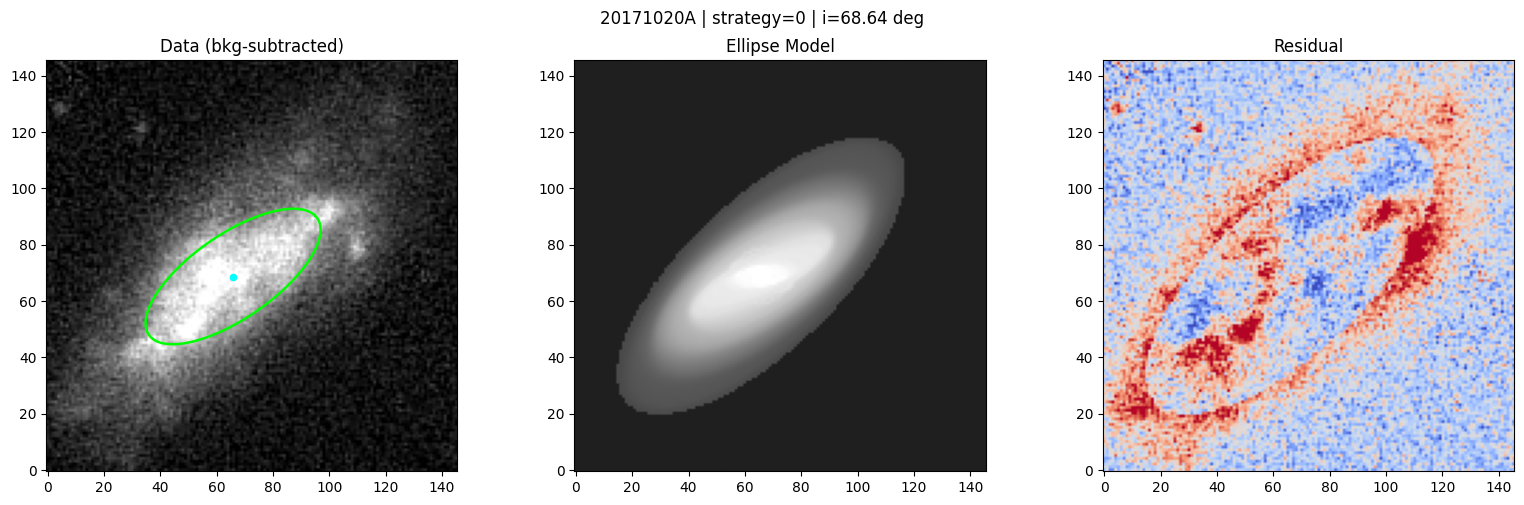

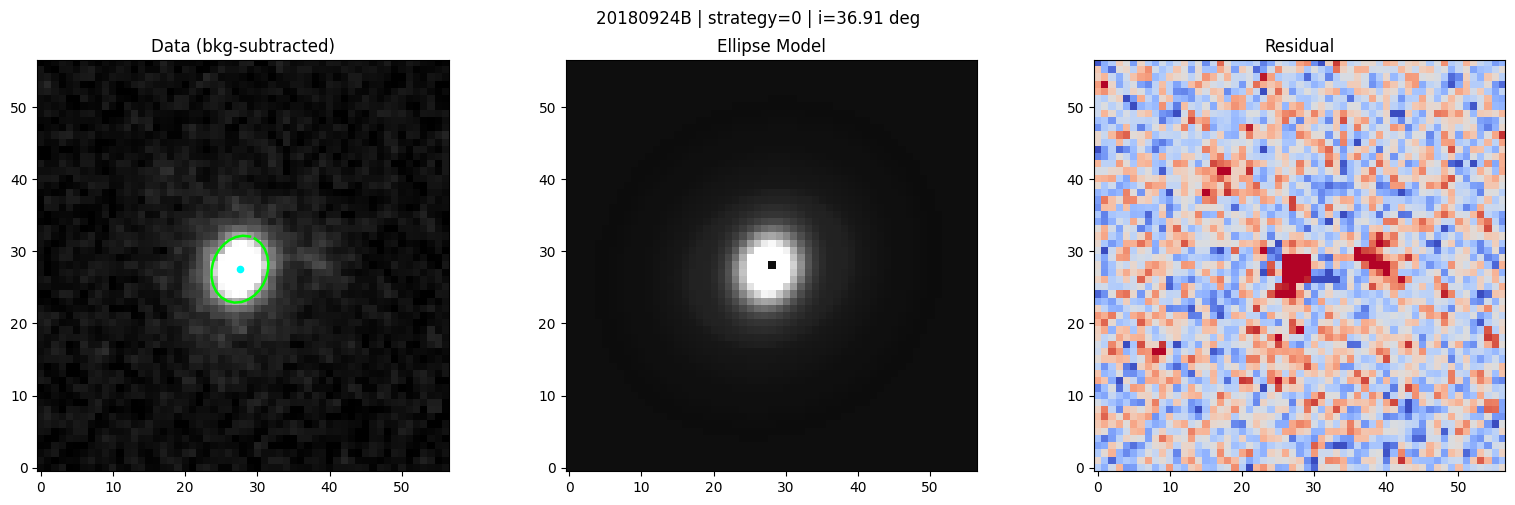

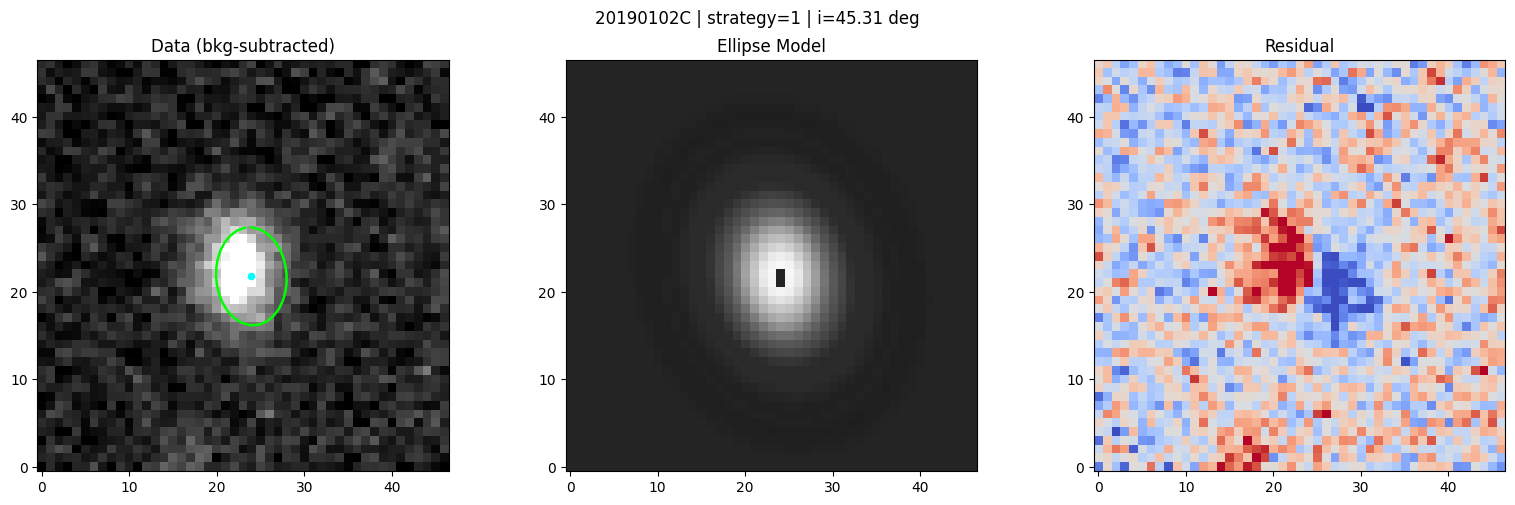

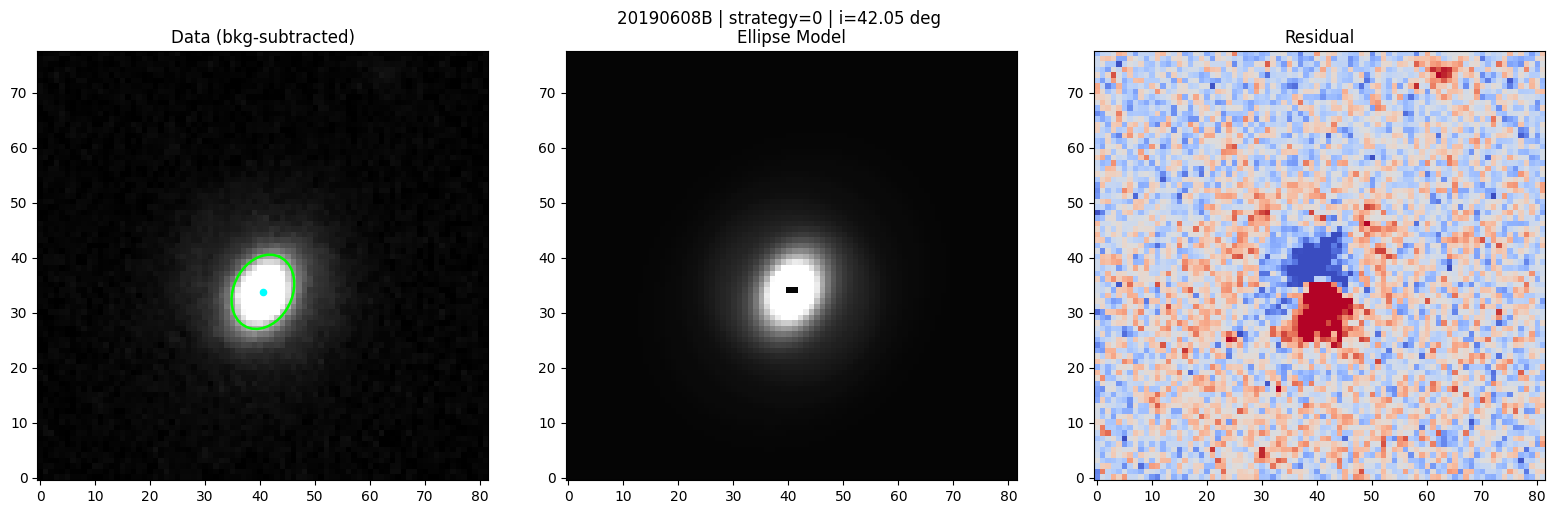

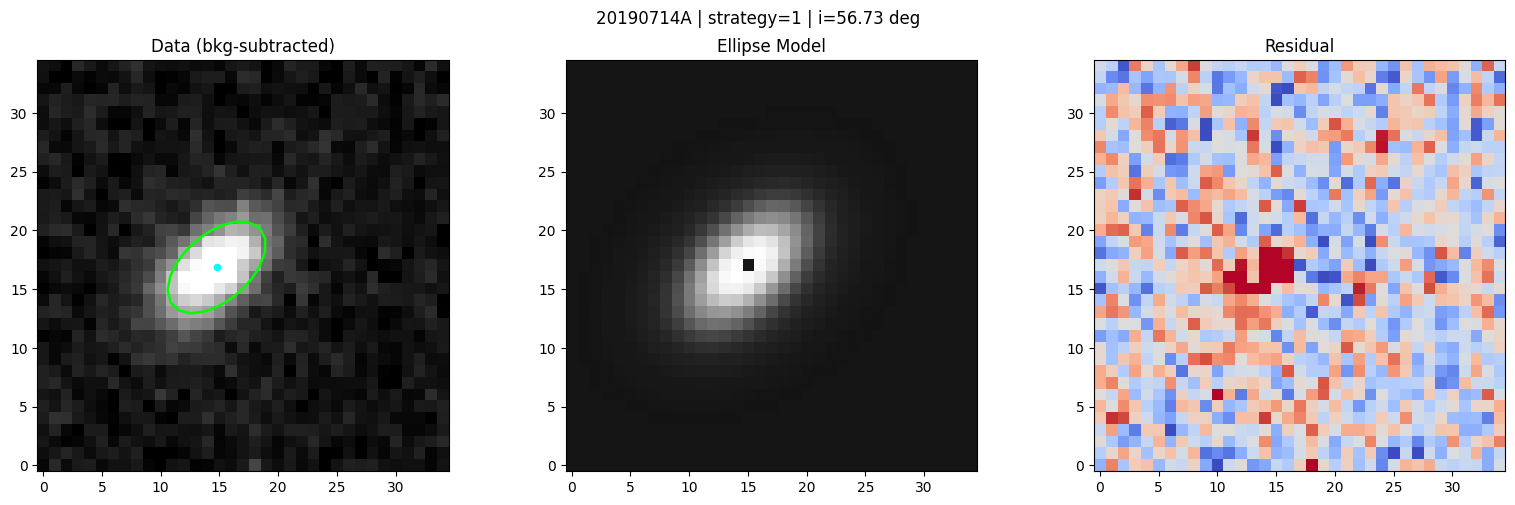

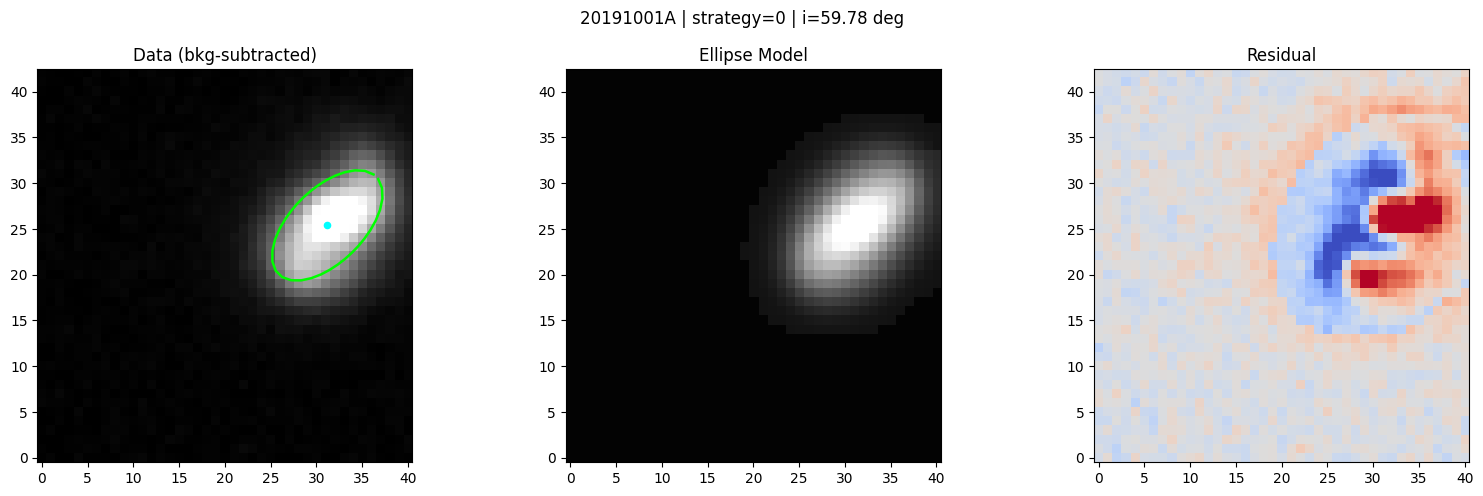

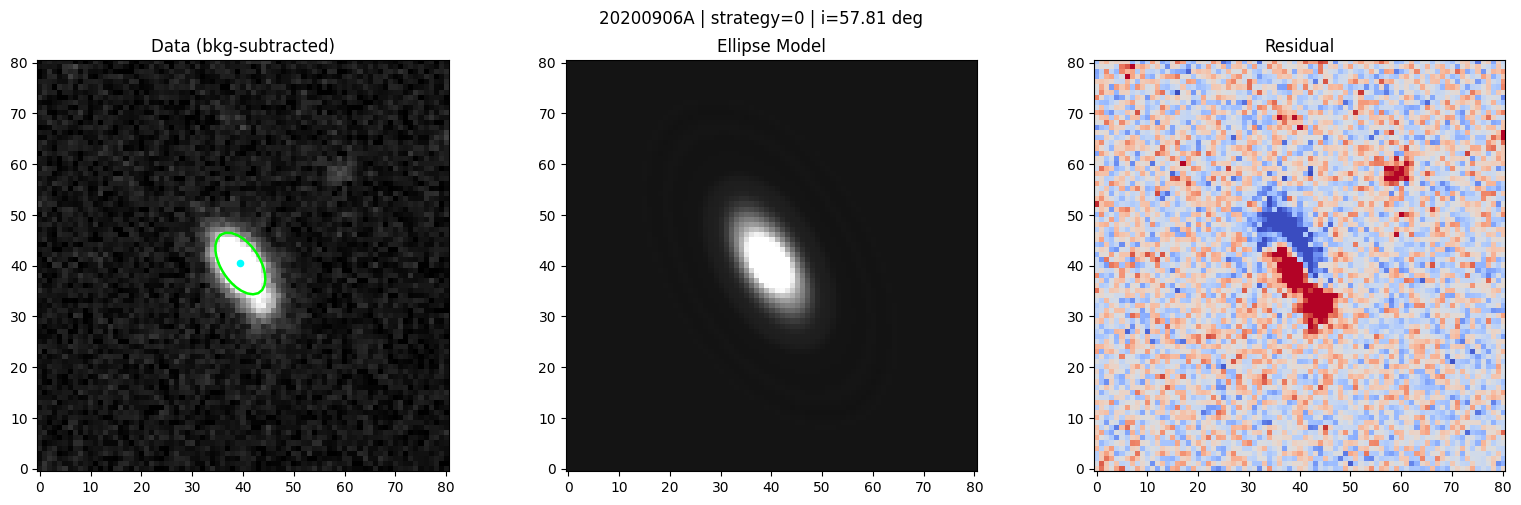

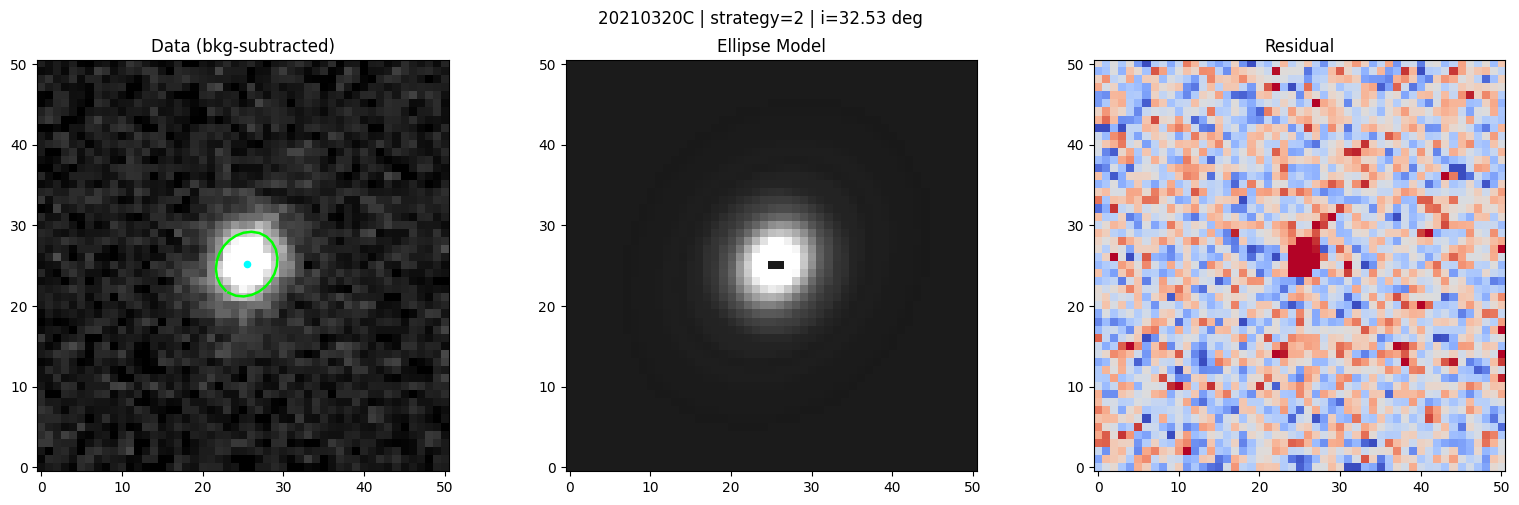

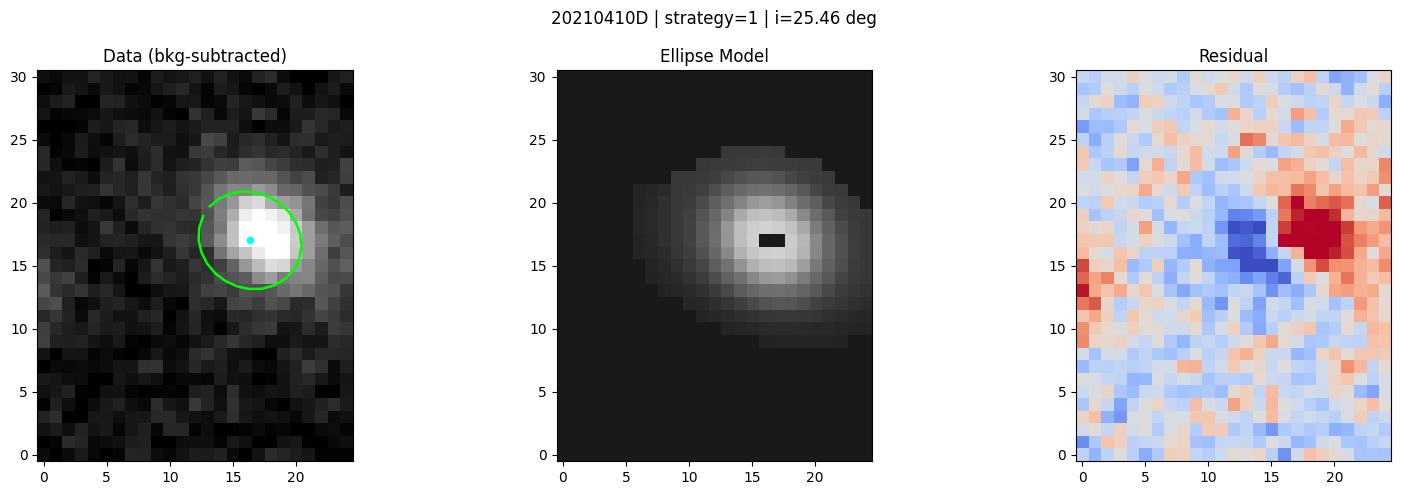

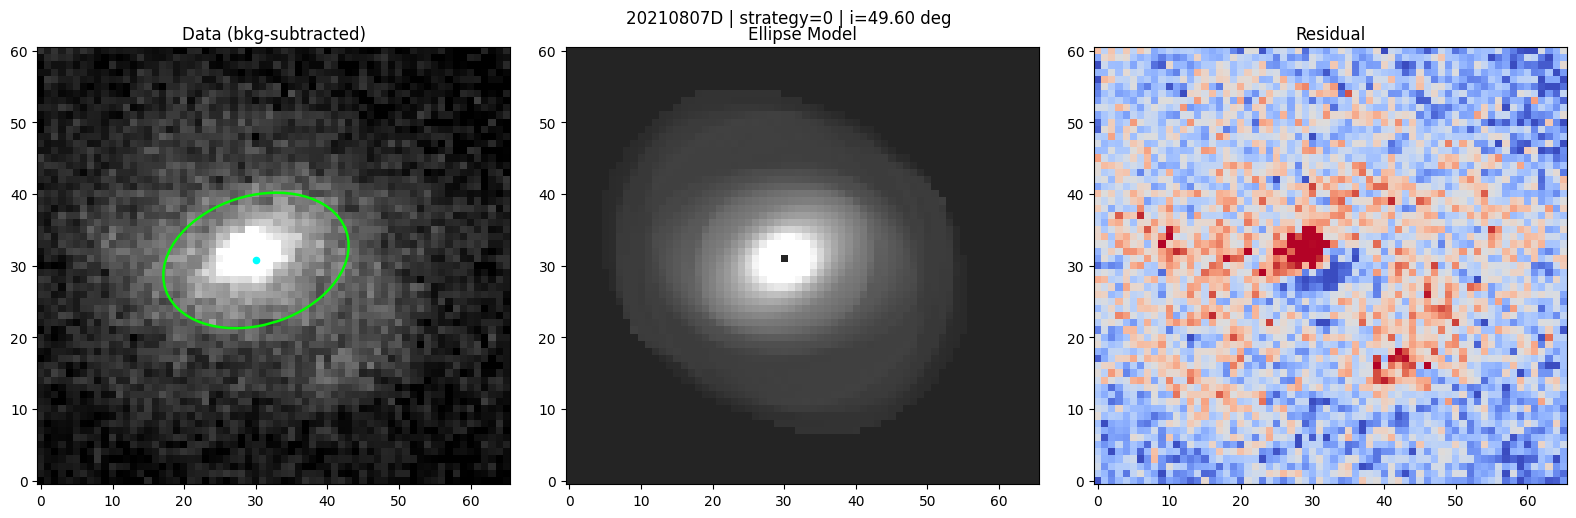

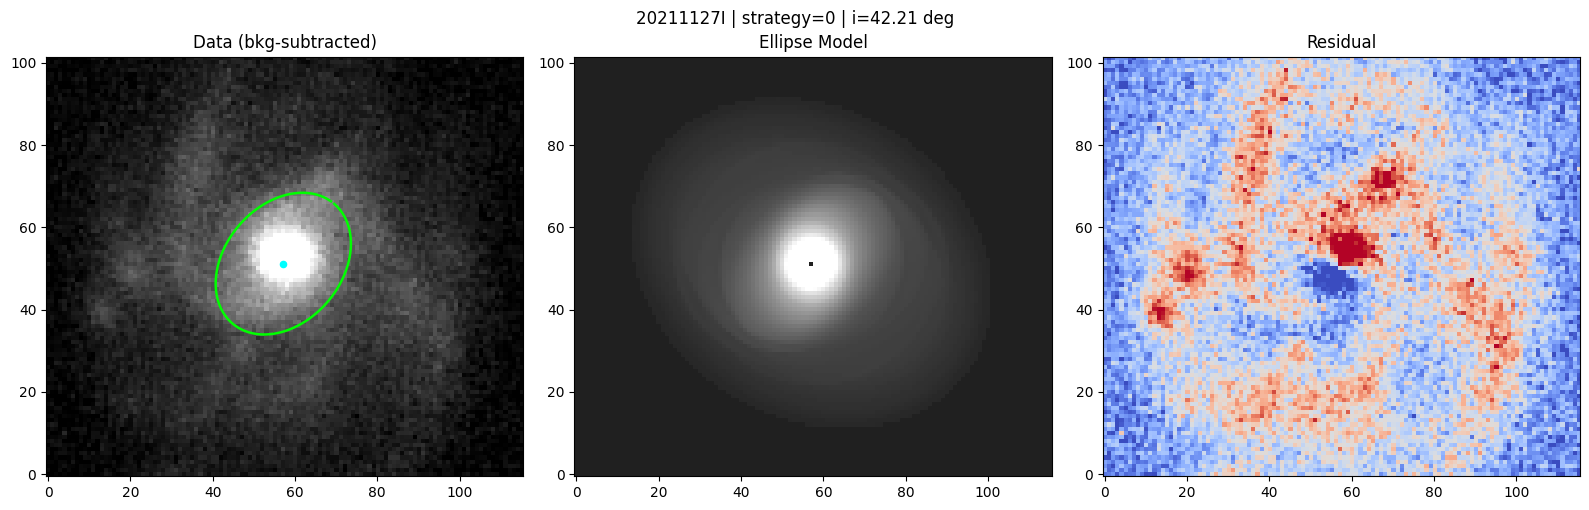

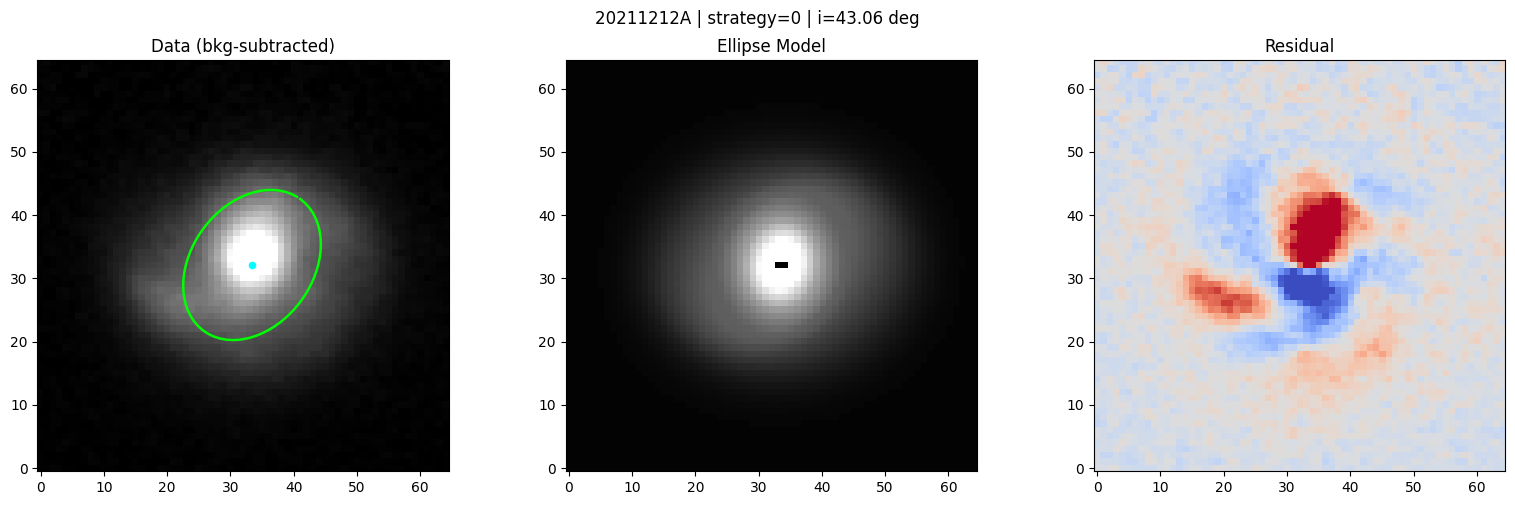

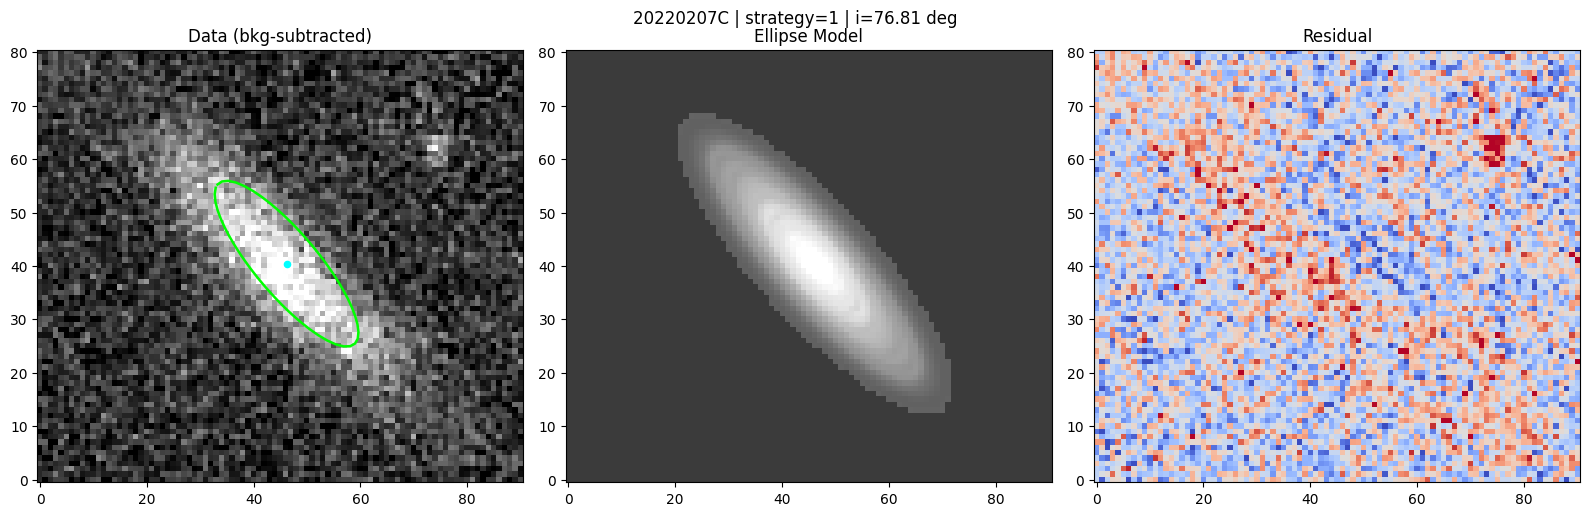

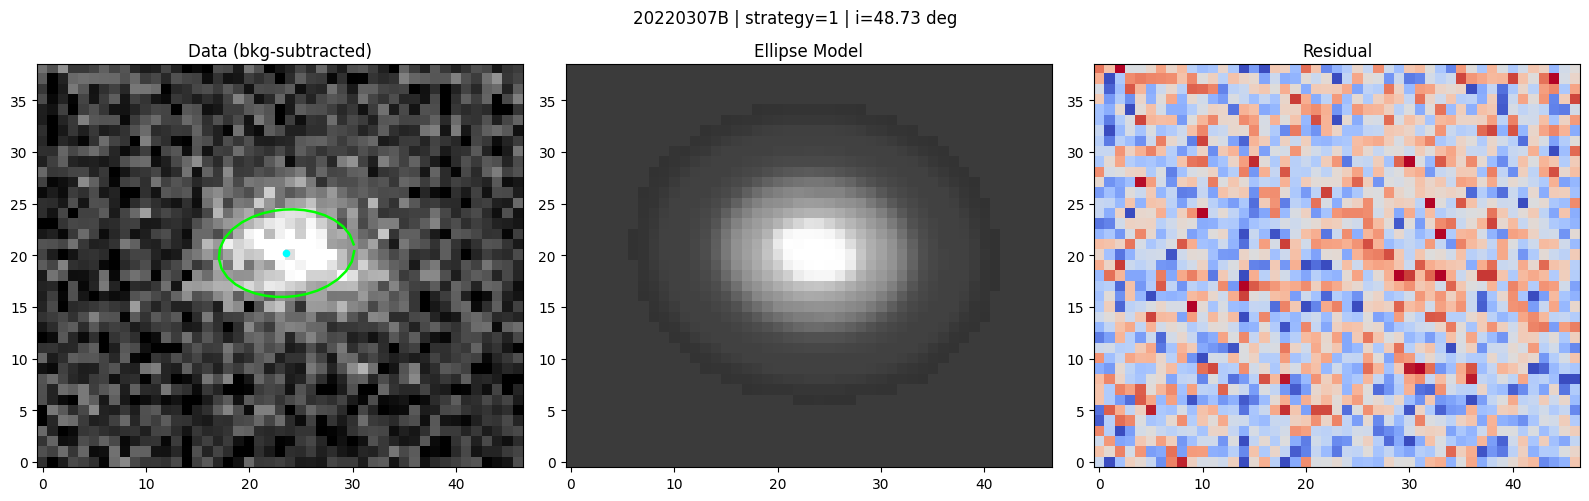

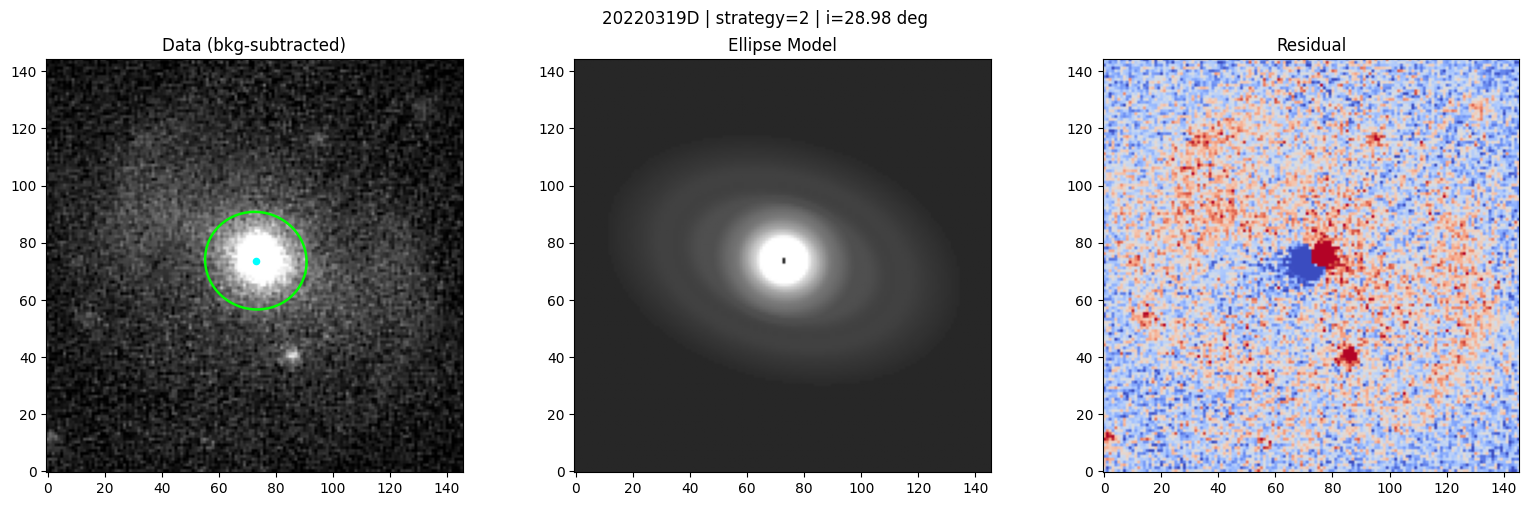

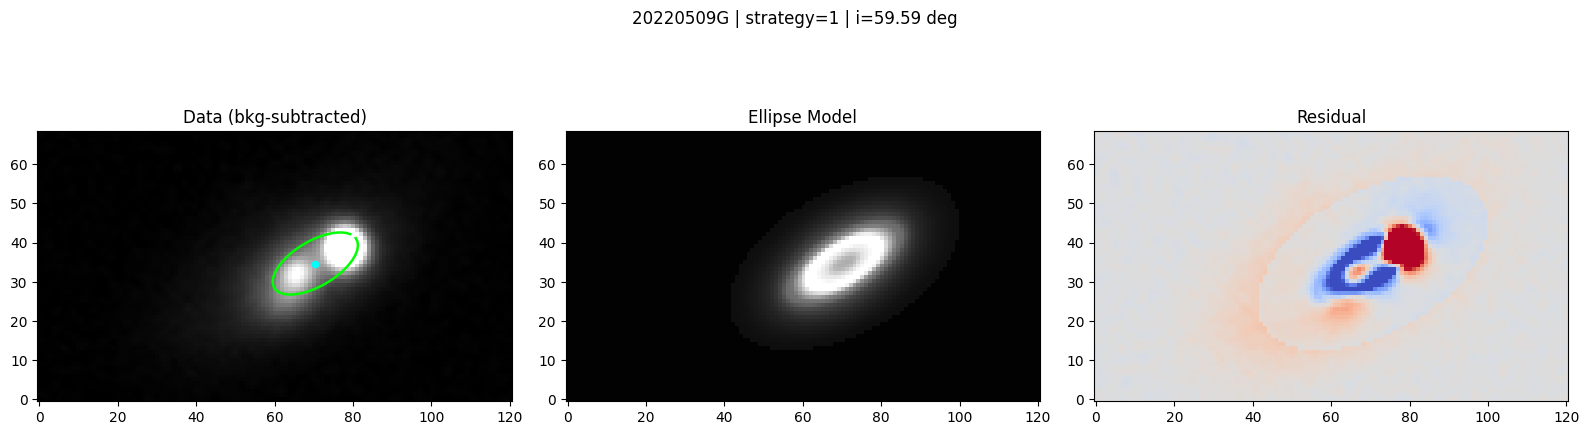

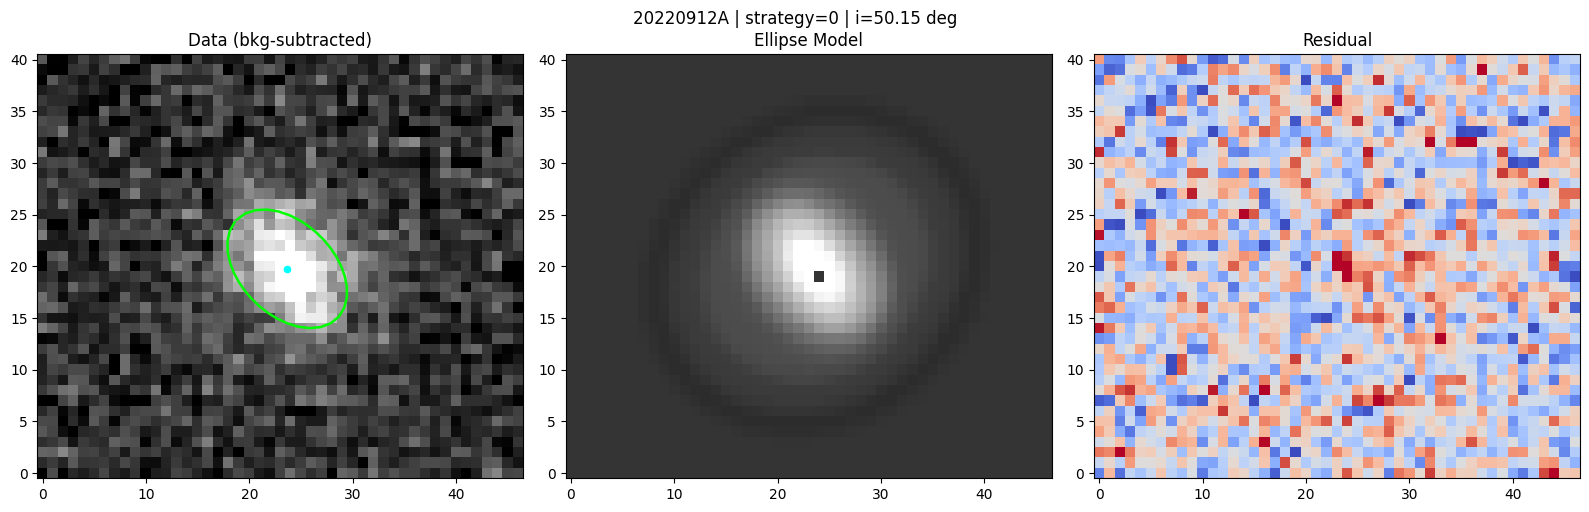

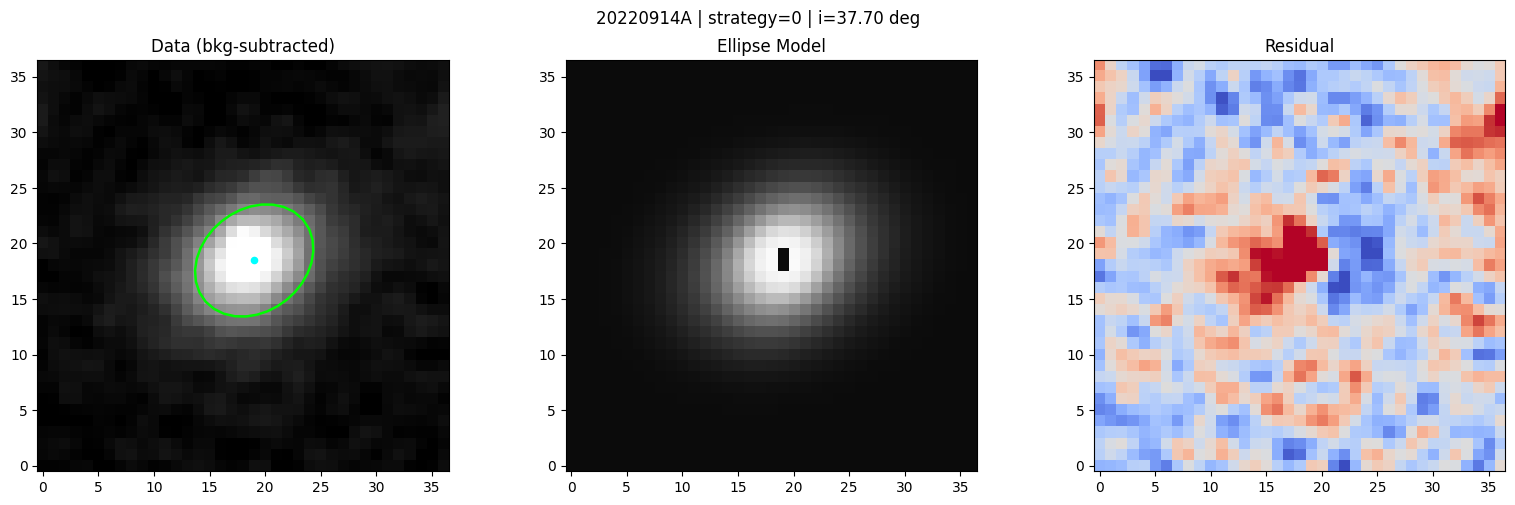

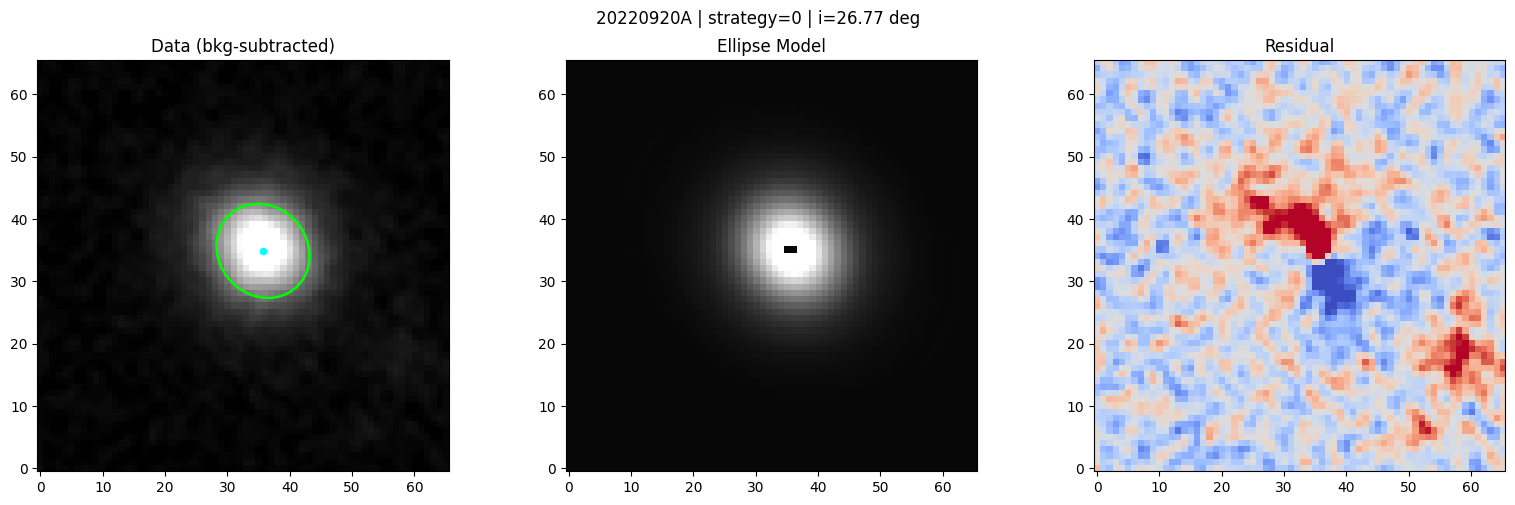

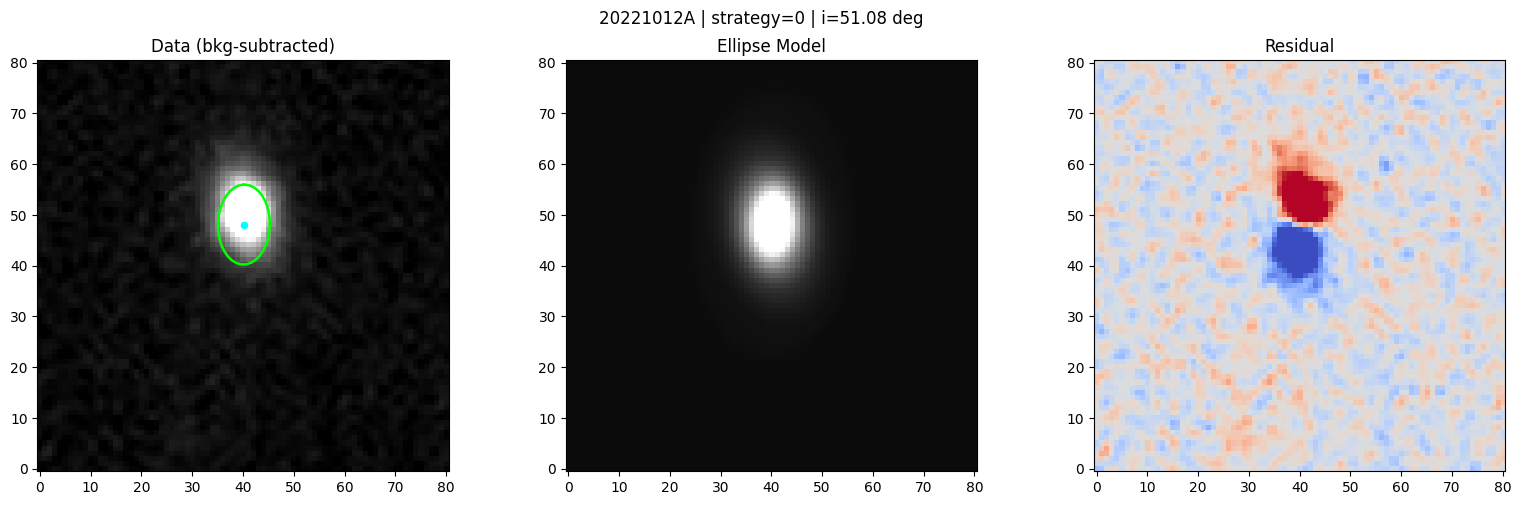

In [12]:
# Visual diagnostics for all successful FRBs: data, ellipse model, residual
ok_rows = res_df[res_df['status'] == 'ok'].copy()
print(f"Rendering diagnostics for {len(ok_rows)} successful fits...")

def _strategy_bank_for_plot(row, image_shape):
    eps = float(np.clip(row['ellipticity_rep'], 0.02, 0.90))
    pa = float(np.radians(row['pa_deg']))
    sma = float(max(MINSMA + 0.5, row['sma_rep_pix']))
    return [
        {'sma': sma, 'eps': eps, 'pa': pa, 'step': STEP, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 0.5, 1.5 * sma), 'eps': eps, 'pa': pa, 'step': 0.06, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 0.5, 0.7 * sma), 'eps': min(0.8, max(0.05, eps)), 'pa': pa, 'step': 0.12, 'fix_center': True, 'fix_pa': True, 'fix_eps': False},
        {'sma': max(MINSMA + 1.0, min(image_shape) * 0.12), 'eps': 0.35, 'pa': 0.0, 'step': 0.08, 'fix_center': True, 'fix_pa': False, 'fix_eps': False},
        {'sma': max(MINSMA + 1.0, min(image_shape) * 0.18), 'eps': 0.5, 'pa': np.pi / 4.0, 'step': 0.08, 'fix_center': False, 'fix_pa': False, 'fix_eps': False},
    ]

for _, r in ok_rows.iterrows():
    frb = r['FRB']
    flux_path = os.path.join(GALAXY_DIR, f'{frb}_flux.fits')
    sigma_path = os.path.join(GALAXY_DIR, f'{frb}_sigma.fits')

    data = np.squeeze(np.asarray(fits.getdata(flux_path), dtype=float))
    sigma = np.squeeze(np.asarray(fits.getdata(sigma_path), dtype=float))
    finite = np.isfinite(data) & np.isfinite(sigma) & (sigma > 0)
    bkg_mean, bkg_med, bkg_std = sigma_clipped_stats(data[finite], sigma=CLIP_SIGMA, maxiters=CLIP_MAXITERS)
    image = data - bkg_med
    image_fit = np.where(finite, image, bkg_med)

    x0 = float(r['x0_pix'])
    y0 = float(r['y0_pix'])
    bank = _strategy_bank_for_plot(r, image.shape)

    iso = None
    used = int(r.get('fit_strategy_index', 0)) if np.isfinite(r.get('fit_strategy_index', np.nan)) else 0
    trial_order = [used] + [i for i in range(len(bank)) if i != used]

    for k in trial_order:
        st = bank[k]
        geom = EllipseGeometry(x0=x0, y0=y0, sma=st['sma'], eps=st['eps'], pa=st['pa'])
        ell = Ellipse(image_fit, geometry=geom)
        try:
            isolist = ell.fit_image(
                minsma=MINSMA,
                maxsma=float(max(MINSMA + 2.0, min(image.shape) * MAXSMA_FRAC)),
                step=st['step'],
                nclip=1,
                fix_center=st['fix_center'],
                fix_pa=st['fix_pa'],
                fix_eps=st['fix_eps'],
            )
            if len(isolist) > 0:
                iso = isolist
                used = k
                break
        except Exception:
            pass

    if iso is None:
        print(f"{frb}: visualization fit failed (no isophotes)")
        continue

    model_image = build_ellipse_model(image_fit.shape, iso)
    residual = image_fit - model_image

    v1, v2 = np.nanpercentile(image_fit, [5, 99])
    vr = np.nanpercentile(np.abs(residual[np.isfinite(residual)]), 98)
    vr = max(vr, 1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"{frb} | strategy={used} | i={r['inclination_deg']:.2f} deg", fontsize=12)

    axes[0].imshow(image_fit, origin='lower', cmap='gray', vmin=v1, vmax=v2)
    axes[0].set_title('Data (bkg-subtracted)')

    axes[1].imshow(model_image, origin='lower', cmap='gray', vmin=v1, vmax=v2)
    axes[1].set_title('Ellipse Model')

    axes[2].imshow(residual, origin='lower', cmap='coolwarm', vmin=-vr, vmax=vr)
    axes[2].set_title('Residual')

    rep_iso = iso.get_closest(float(r['sma_rep_pix']))
    x, y = rep_iso.sampled_coordinates()
    axes[0].plot(x, y, color='lime', linewidth=1.8)
    axes[0].scatter(x0, y0, c='cyan', s=20)

    plt.tight_layout()
    plt.show()